# Work in progess...

In [1]:
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np

from darts import TimeSeries
from darts.datasets import AirPassengersDataset
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Get era5 data and keep Fennoscandia

In [2]:
# get era5 data

df = pyreadr.read_r('../Data/era5_met.rds')[None]
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [3]:
df

,station_id,date,tair,tp,sf,year,month
0,3_1,1960-01-01,270.935638,1.024788e-02,1.024122e-02,1960,1
1,3_1,1960-01-02,268.549255,8.457695e-03,8.453619e-03,1960,1
2,3_1,1960-01-03,265.638245,1.111615e-06,5.234033e-07,1960,1
3,3_1,1960-01-04,264.218536,1.451688e-05,1.340872e-05,1960,1
4,3_1,1960-01-05,265.721497,9.060125e-04,9.025466e-04,1960,1
...,...,...,...,...,...,...,...
28246037,1177_1,2024-06-26,287.689789,2.659548e-04,0.000000e+00,2024,6
28246038,1177_1,2024-06-27,285.414764,1.099903e-03,0.000000e+00,2024,6
28246039,1177_1,2024-06-28,284.358337,4.007968e-03,1.303852e-08,2024,6
28246040,1177_1,2024-06-29,286.996796,7.222891e-05,0.000000e+00,2024,6


In [4]:
lakes = pyreadr.read_r('../Data/ltbl_ice.rds')[None]
fs_lakes = set(lakes.loc[lakes['lon_wgs84'] > 0, 'station_id'].unique())
fin_lakes = set(lakes.loc[lakes['country'] == 'FI', 'station_id'].unique())

In [5]:
df = df.loc[df['station_id'].isin(fs_lakes), :]

## Merge with ice on ice off data

In [6]:
ice = pyreadr.read_r('../Data/data_ip.rds')[None]

ice['ice_on'] = pd.to_datetime(ice['ice_on'])
ice['ice_off'] = pd.to_datetime(ice['ice_off'])
ice['year'] = ice['year'].astype(int)

# keep fs lakes
ice = ice.loc[ice['station_id'].isin(fs_lakes), :]

# keep where both not null
ice = ice[ice[['ice_on', 'ice_off']].notnull().all(axis=1)]

# cut to same dates as in era and subset to same stations
ice = ice.loc[ice['ice_on'] >= df['date'].min(), :]
ice = ice.loc[ice['ice_off'] <= df['date'].max(), :]

/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


### Group all time series by 4 year period bins and keep complete only

In [7]:
bins = pd.interval_range(start=ice['year'].min(), end=ice['year'].max(),
                        periods=4)
bins

IntervalIndex([(1960, 1976], (1976, 1992], (1992, 2008], (2008, 2024]], dtype='interval[int64, right]')

In [8]:
ice['bin'] = pd.cut(ice['year'], bins)
ice

,station_id,year,ice_on,ice_off,bin
11,3_1,1961,1960-11-01,1961-05-30,"(1960, 1976]"
12,3_1,1962,1961-11-28,1962-05-30,"(1960, 1976]"
13,3_1,1963,1962-11-18,1963-05-24,"(1960, 1976]"
14,3_1,1964,1963-11-12,1964-05-30,"(1960, 1976]"
15,3_1,1965,1964-11-09,1965-06-02,"(1960, 1976]"
...,...,...,...,...,...
31401,811_1,1982,1981-12-06,1982-04-06,"(1976, 1992]"
31402,811_1,1983,1982-12-10,1983-04-20,"(1976, 1992]"
31412,798_1,1961,1960-11-20,1961-05-15,"(1960, 1976]"
31417,798_1,1966,1965-11-13,1966-05-25,"(1960, 1976]"


In [9]:
def is_complete(_bin, group):
    # assume right interval
    
    years_in_group = set(group['year'].unique())
    years_in_bin = set(range(_bin.left+1, _bin.right+1))
    
    return len(years_in_bin.difference(years_in_group)) == 0

In [10]:
gb = ice.groupby([pd.cut(ice['year'], bins), 'station_id'])

n_complete = {}
complete_groups = []

for idx, (group_id, group_df) in enumerate(gb):
    _bin = group_df['bin'].iloc[0]
    
    if is_complete(_bin, group_df):
        complete_groups.append(group_df)
        try:
            n_complete[_bin] += 1
        except KeyError:
            n_complete[_bin] = 1
        
print(n_complete)

/tmp/ipykernel_76478/1424866502.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = ice.groupby([pd.cut(ice['year'], bins), 'station_id'])


{Interval(1960, 1976, closed='right'): 241, Interval(1976, 1992, closed='right'): 220, Interval(1992, 2008, closed='right'): 74, Interval(2008, 2024, closed='right'): 28}


In [11]:
ice = pd.concat(complete_groups)

#### Plot

In [12]:
ice['year_on_diff'] = (pd.to_datetime(ice['year'], format='%Y') - pd.to_datetime(ice['ice_on'])).dt.days 
ice

,station_id,year,ice_on,ice_off,bin,year_on_diff
3042,114_1,1961,1960-10-25,1961-06-01,"(1960, 1976]",68
3043,114_1,1962,1961-11-26,1962-05-31,"(1960, 1976]",36
3044,114_1,1963,1962-11-12,1963-05-18,"(1960, 1976]",50
3045,114_1,1964,1963-11-06,1964-05-21,"(1960, 1976]",56
3046,114_1,1965,1964-11-12,1965-05-27,"(1960, 1976]",50
...,...,...,...,...,...,...
27638,726_1,2020,2019-10-22,2020-06-03,"(2008, 2024]",71
27639,726_1,2021,2020-11-10,2021-05-29,"(2008, 2024]",52
27640,726_1,2022,2021-10-20,2022-05-25,"(2008, 2024]",73
27641,726_1,2023,2022-11-12,2023-05-21,"(2008, 2024]",50


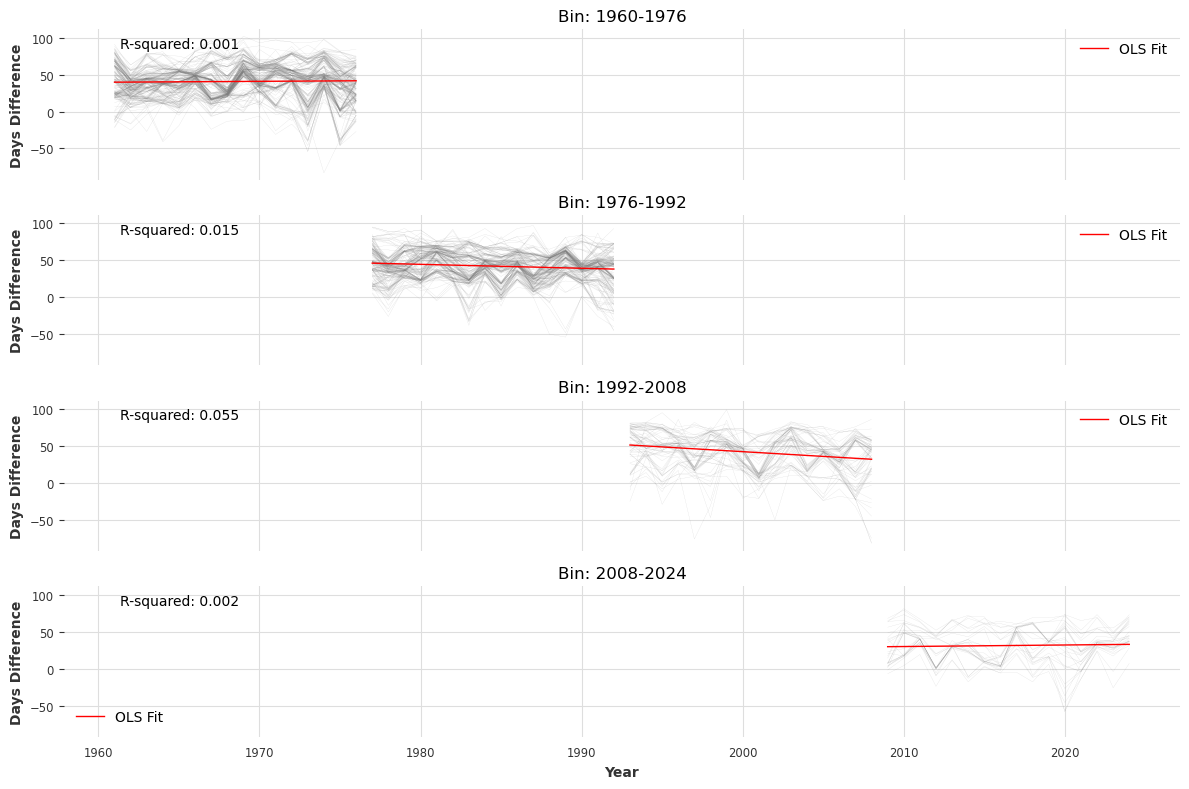

In [13]:
import statsmodels.api as sm

fig, axes = plt.subplots(len(bins), 1, figsize=(12, 8), sharex=True, sharey=True)

for i, bin_interval in enumerate(bins):
    ax = axes[i]
    bin_df = ice[ice['bin'] == bin_interval]
    
    for station_id in bin_df['station_id'].unique():
        station_df = bin_df[bin_df['station_id'] == station_id]
        
        # plot data
        ax.plot(station_df['year'], station_df['year_on_diff'], 
                label='', color='gray', alpha=0.5, linewidth=0.1)

    # Make and plot OLS model
    
    # Prepare data for regression
    X = bin_df['year'].values 
    y = bin_df['year_on_diff'].values
    
    # Add constant and squared term for polynomial regression
    # X = sm.add_constant(np.column_stack((X, X**2)))
    X = sm.add_constant(X)
    
    # Fit the model
    model = sm.OLS(y, X).fit()
    
    # Generate predictions
    x_smooth = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    # X_pred = sm.add_constant(np.column_stack((x_smooth, x_smooth**2)))
    X_pred = sm.add_constant(x_smooth)
    y_pred = model.predict(X_pred)

    ax.plot(x_smooth, y_pred, color='red', linewidth=1, 
            label='OLS Fit')

    # Add R-squared value to the plot
    ax.text(0.05, 0.95, f'R-squared: {model.rsquared:.3f}', 
            transform=ax.transAxes, 
            verticalalignment='top')

    
    ax.set_title(f'Bin: {bin_interval.left}-{bin_interval.right}')
    ax.set_ylabel('Days Difference')
    ax.legend()

plt.xlabel('Year')
plt.tight_layout()



### Box-plots

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Group data by bins
box_data = [ice[ice['bin'] == bin_interval]['year_on_diff'] for bin_interval in bins]

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*box_data)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    # Create a DataFrame for Tukey's HSD
    tukey_data = pd.DataFrame({
        'year_on_diff': ice['year_on_diff'],
        'bin': ice['bin'].apply(lambda x: f'{x.left}-{x.right}')
    })
    
    tukey_result = pairwise_tukeyhsd(tukey_data['year_on_diff'], tukey_data['bin'])
    print(tukey_result)

    # Extract group labels from Tukey's HSD results
    group_labels = {group: label for group, label in zip(tukey_result.groupsunique, tukey_result._results_table.data[1:])}
else:
    print("No significant differences found between groups.")
    group_labels = {f'{bin_interval.left}-{bin_interval.right}': 'a' for bin_interval in bins}



ANOVA F-statistic: 34.10, p-value: 0.0000
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
1960-1976 1976-1992    1.432 0.0241   0.1319  2.7321   True
1960-1976 1992-2008   0.9562 0.5464  -0.8969  2.8092  False
1960-1976 2008-2024  -9.4858    0.0 -12.2696  -6.702   True
1976-1992 1992-2008  -0.4759 0.9147  -2.3495  1.3978  False
1976-1992 2008-2024 -10.9178    0.0 -13.7154 -8.1202   True
1992-2008 2008-2024  -10.442    0.0 -13.5355 -7.3484   True
-----------------------------------------------------------


In [15]:
def assign_cld(tukey_results, alpha=0.05):
    """
    Assign Compact Letter Display (CLD) labels based on Tukey's HSD results.
    """
    groups = tukey_results.groupsunique
    n_groups = len(groups)
    
    # Initialize a dictionary to store group letters
    cld = {group: set() for group in groups}
    
    # Start assigning letters
    current_letter = 97  # ASCII code for 'a'
    
    for i in range(n_groups):
        for j in range(i + 1, n_groups):
            group1, group2 = groups[i], groups[j]
            p_value = tukey_results.pvalues[n_groups * i + j - ((i + 1) * (i + 2)) // 2]
            
            if p_value < alpha:
                # Groups are significantly different; ensure they do not share a letter
                if not cld[group1]:
                    cld[group1].add(chr(current_letter))
                    current_letter += 1
                if not cld[group2]:
                    cld[group2].add(chr(current_letter))
                    current_letter += 1
            else:
                # Groups are not significantly different; they can share a letter
                if not cld[group1] and not cld[group2]:
                    cld[group1].add(chr(current_letter))
                    cld[group2].add(chr(current_letter))
                    current_letter += 1
                elif cld[group1] and not cld[group2]:
                    cld[group2] = cld[group1]
                elif not cld[group1] and cld[group2]:
                    cld[group1] = cld[group2]
                else:
                    # Merge letters if both already have labels
                    cld[group1].update(cld[group2])
                    cld[group2] = cld[group1]
    
    # Convert sets to strings for easier display
    return {group: ''.join(sorted(letters)) for group, letters in cld.items()}
    
group_labels = assign_cld(tukey_result)
group_labels


{'1960-1976': 'a', '1976-1992': 'ab', '1992-2008': 'ab', '2008-2024': 'c'}

In [16]:
tukey_result.groupsunique

array(['1960-1976', '1976-1992', '1992-2008', '2008-2024'], dtype=object)

In [17]:
tukey_result._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
1960-1976,1976-1992,1.432,0.0241,0.1319,2.7321,True
1960-1976,1992-2008,0.9562,0.5464,-0.8969,2.8092,False
1960-1976,2008-2024,-9.4858,0.0,-12.2696,-6.702,True
1976-1992,1992-2008,-0.4759,0.9147,-2.3495,1.3978,False
1976-1992,2008-2024,-10.9178,0.0,-13.7154,-8.1202,True
1992-2008,2008-2024,-10.442,0.0,-13.5355,-7.3484,True


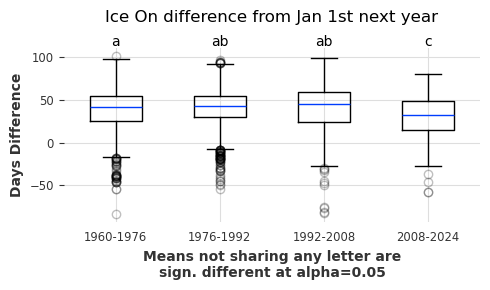

In [18]:
# Plot box plots with significance labels

fig, ax = plt.subplots(figsize=(5, 3))

positions = range(1, len(bins) + 1)

box_plot = ax.boxplot(box_data, positions=positions, widths=0.5)

for flier in box_plot['fliers']:
    flier.set(marker='o', 
              markerfacecolor='none',
              markeredgecolor='black', 
              alpha=0.25,
              markersize=6)

# Set x-tick labels to bin ranges
ax.set_xticks(positions)
ax.set_xticklabels([f'{bin_interval.left}-{bin_interval.right}' for bin_interval in bins])

# Add significance labels above each box plot
for i, bin_interval in enumerate(bins):
    label = group_labels.get(f'{bin_interval.left}-{bin_interval.right}', 'NA')
    ax.text(positions[i], 110, # max(box_data) + 0.5
            label,
            horizontalalignment='center', verticalalignment='bottom')

ax.set_xlabel('Means not sharing any letter are\nsign. different at alpha=0.05')
ax.set_ylabel('Days Difference')
ax.set_title('Ice On difference from Jan 1st next year\n')

plt.tight_layout()
plt.show()


### TODO: Trends with Darts

import copy 

ice_w_idx = copy.deepcopy(ice)
ice_w_idx.set_index(['year', 'station_id'], inplace=True)
ice_w_idx.index = ice_w_idx.index.map(lambda x: f"{x[0]}_{x[1]}")

ice_w_idx['year'] = ice['year']
ice_w_idx



from darts.utils.statistics import extract_trend_and_seasonality
from darts.timeseries import concatenate

fig, axes = plt.subplots(len(bins), 1, figsize=(12, 8), sharex=True, sharey=True)

for i, bin_interval in enumerate(bins):
    ax = axes[i]
    bin_df = ice[ice['bin'] == bin_interval]
    
    # Prepare TimeSeries object for Darts
    # ts = TimeSeries.from_dataframe(bin_df, value_cols='year_on_diff')
    
    ts = TimeSeries.from_group_dataframe(
        bin_df,
        group_cols=['station_id'],
        time_col='year',
        value_cols=['year_on_diff']
    )

    ts = concatenate(ts, axis=1)
    
    # Extract trend component using Darts
    trend, _ = extract_trend_and_seasonality(ts, method='naive', model='additive')
    
    # Plot original data
    ts.plot(ax=ax, label='Original Data', color='gray', alpha=0.5)
    
    # Plot extracted trend
    trend.plot(ax=ax, label='Trend', color='red', linewidth=2)
    
    ax.set_title(f'Bin: {bin_interval.left}-{bin_interval.right}')
    ax.set_ylabel('Days Difference')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

plt.xlabel('Year')
plt.tight_layout()